# Project 1: Advanced EDA & Feature Engineering
**DecodeLabs Industrial Training Kit — Batch 2026**

**Goal:** Transform a raw, chaotic dataset into a mathematically clean dataset ready for machine learning, by:
1. Handling missing data via statistical imputation (Mean/Median/KNN)
2. Identifying and neutralizing outliers using the IQR method
3. Engineering at least 3 new predictive features

> **Note on the dataset:** No dataset was supplied for this run, so a synthetic **"ShopSphere" e-commerce customer dataset**
> is generated below with realistic messiness (missing-data bands, outliers, and a deliberately redundant/collinear
> column) so every technique in the brief has something real to act on. If you have your own assigned dataset,
> replace **Section 1** with `df = pd.read_csv("your_file.csv")` — everything from Section 2 onward will still apply.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RNG = np.random.default_rng(42)


## 1. Generate the Raw Dataset

`ShopSphere` — an e-commerce customer table. It is built with intentional flaws so we can exercise every rule in the
DecodeLabs missing-data decision matrix and the IQR outlier protocol:

| Column | Issue baked in |
|---|---|
| `age` | ~2% missing (**<5% band**), a few impossible values (negative / >100) |
| `city` | ~3% missing (**<5% band**) |
| `gender` | ~7% missing (**5–20% band**), categorical |
| `annual_income` | ~14% missing (**5–20% band**), skewed, extreme high-earner outliers |
| `membership_years` | ~9% missing (**5–20% band**), correlated with `city` |
| `satisfaction_score` | ~24% missing (**>20% band**) |
| `num_purchases_last_year` / `avg_purchase_value` | spike outliers |
| `monthly_income` | deliberately **redundant** with `annual_income` (near-perfect collinearity) |


In [2]:
n = 1200
customer_id = np.arange(1, n + 1)

age = RNG.normal(38, 12, n).round().astype(float)
# inject a handful of impossible outliers
outlier_idx = RNG.choice(n, 8, replace=False)
age[outlier_idx[:4]] = RNG.integers(150, 200, 4)
age[outlier_idx[4:]] = -RNG.integers(1, 10, 4)

city = RNG.choice(
    ["Karachi", "Lahore", "Islamabad", "Rawalpindi", "Faisalabad"],
    n, p=[0.28, 0.26, 0.18, 0.16, 0.12]
).astype(object)

gender = RNG.choice(["Male", "Female"], n, p=[0.52, 0.48]).astype(object)

# income: lognormal (skewed) with a handful of extreme earners
annual_income = RNG.lognormal(mean=13.2, sigma=0.4, size=n)
rich_idx = RNG.choice(n, 6, replace=False)
annual_income[rich_idx] *= RNG.uniform(6, 10, 6)

# monthly_income: near-duplicate of annual_income -> deliberate multicollinearity
monthly_income = annual_income / 12 + RNG.normal(0, 40, n)

city_base_tenure = {"Karachi": 5, "Lahore": 6, "Islamabad": 4, "Rawalpindi": 4.5, "Faisalabad": 3.5}
membership_years = np.array([
    max(0, RNG.normal(city_base_tenure[c], 2.2)) for c in city
]).round(1)

device_type = RNG.choice(["Mobile", "Desktop", "Tablet"], n, p=[0.6, 0.3, 0.1]).astype(object)
email_signup = RNG.choice(["Yes", "No"], n, p=[0.55, 0.45]).astype(object)

num_purchases_last_year = RNG.poisson(9, n).astype(float)
spike_idx = RNG.choice(n, 10, replace=False)
num_purchases_last_year[spike_idx] += RNG.integers(80, 200, 10)

avg_purchase_value = RNG.gamma(shape=3.0, scale=1800, size=n)
spike_idx2 = RNG.choice(n, 10, replace=False)
avg_purchase_value[spike_idx2] *= RNG.uniform(6, 12, 10)

total_spent = (num_purchases_last_year * avg_purchase_value * RNG.uniform(0.85, 1.15, n)).round(2)

last_purchase_days_ago = RNG.exponential(70, n).round().clip(0, 400)

satisfaction_score = RNG.normal(7, 1.8, n).round(1).clip(1, 10)

# churn target: driven by recency, low satisfaction, low purchase frequency + noise
churn_logit = (
    0.02 * last_purchase_days_ago
    - 0.55 * satisfaction_score
    - 0.08 * num_purchases_last_year
    + RNG.normal(0, 1.1, n)
)
churn_prob = 1 / (1 + np.exp(-(churn_logit - churn_logit.mean()) / churn_logit.std()))
churned = (RNG.uniform(0, 1, n) < churn_prob).astype(int)

df = pd.DataFrame({
    "customer_id": customer_id,
    "age": age,
    "gender": gender,
    "city": city,
    "annual_income": annual_income.round(2),
    "monthly_income": monthly_income.round(2),
    "membership_years": membership_years,
    "device_type": device_type,
    "email_signup": email_signup,
    "num_purchases_last_year": num_purchases_last_year,
    "avg_purchase_value": avg_purchase_value.round(2),
    "total_spent": total_spent,
    "last_purchase_days_ago": last_purchase_days_ago,
    "satisfaction_score": satisfaction_score,
    "churned": churned,
})

# inject missingness at controlled rates
def inject_missing(frame, col, frac):
    idx = RNG.choice(frame.index, int(len(frame) * frac), replace=False)
    frame.loc[idx, col] = np.nan

inject_missing(df, "age", 0.02)
inject_missing(df, "city", 0.03)
inject_missing(df, "gender", 0.07)
inject_missing(df, "annual_income", 0.14)
inject_missing(df, "membership_years", 0.09)
inject_missing(df, "satisfaction_score", 0.24)

df.to_csv("shopsphere_raw.csv", index=False)
df.head()


,customer_id,age,gender,city,annual_income,monthly_income,membership_years,device_type,email_signup,num_purchases_last_year,avg_purchase_value,total_spent,last_purchase_days_ago,satisfaction_score,churned
0,1,42.0,Female,Faisalabad,938944.46,78235.89,6.4,Tablet,No,6.0,4137.80,25043.55,1.0,8.5,0
1,2,NaN,NaN,Faisalabad,1056675.19,88084.87,3.5,Mobile,No,7.0,6411.71,45529.06,146.0,4.5,0
2,3,47.0,Female,Karachi,719951.68,59961.97,4.1,Mobile,No,9.0,825.31,7005.66,177.0,NaN,0
3,4,49.0,Female,Karachi,335662.88,27919.67,3.8,Mobile,Yes,11.0,5915.43,71984.50,4.0,NaN,0
4,5,15.0,Female,Karachi,657528.09,54791.15,3.8,Desktop,No,4.0,7487.65,27324.08,216.0,7.4,1


## 2. Initial Inspection

Before touching anything, quantify exactly how "chaotic" the data is: shape, dtypes, and — critically — the
per-column missingness percentage that will drive every decision in Section 3.


In [3]:
print("Shape:", df.shape)
df.info()


Shape: (1200, 15)
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1200 non-null   int64  
 1   age                      1176 non-null   float64
 2   gender                   1116 non-null   str    
 3   city                     1164 non-null   str    
 4   annual_income            1032 non-null   float64
 5   monthly_income           1200 non-null   float64
 6   membership_years         1092 non-null   float64
 7   device_type              1200 non-null   str    
 8   email_signup             1200 non-null   str    
 9   num_purchases_last_year  1200 non-null   float64
 10  avg_purchase_value       1200 non-null   float64
 11  total_spent              1200 non-null   float64
 12  last_purchase_days_ago   1200 non-null   float64
 13  satisfaction_score       912 non-null    float64
 14  churned          

satisfaction_score    24.0
annual_income         14.0
membership_years       9.0
gender                 7.0
city                   3.0
age                    2.0
dtype: float64


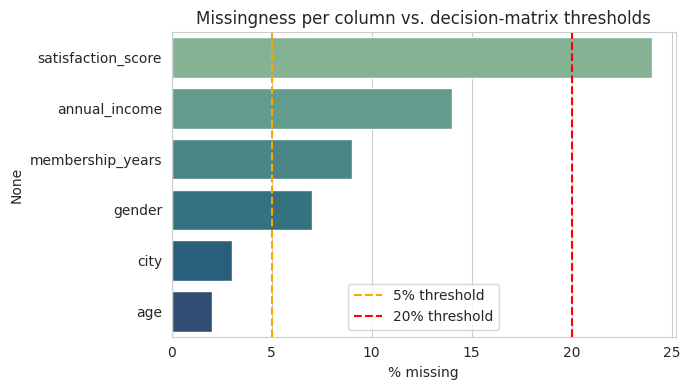

In [4]:
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct)

plt.figure(figsize=(7, 4))
sns.barplot(x=missing_pct.values, y=missing_pct.index, hue=missing_pct.index, palette="crest", legend=False)
plt.axvline(5, color="orange", linestyle="--", label="5% threshold")
plt.axvline(20, color="red", linestyle="--", label="20% threshold")
plt.xlabel("% missing")
plt.title("Missingness per column vs. decision-matrix thresholds")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Phase 1 — Handling Missing Data (Decision Matrix)

Following the DecodeLabs missing-data decision matrix — never guess, apply the threshold rules:

| Missingness | Rule applied here |
|---|---|
| `age`, `city` (**< 5%**) | Row deletion (`dropna`) — preserves distribution, no synthetic values |
| `annual_income` (**5–20%**, skewed) | Global median imputation — robust to the extreme high-earner outliers |
| `membership_years` (**5–20%**, correlated with `city`) | Group-wise conditional imputation — median **per city** |
| `gender` (**5–20%**, categorical) | Mode imputation |
| `satisfaction_score` (**> 20%**) | KNN imputation — captures multi-dimensional relationships other numeric columns encode |


In [5]:
before_rows = len(df)

# --- <5%: row deletion ---
df = df.dropna(subset=["age", "city"])
print(f"Dropped {before_rows - len(df)} rows for <5%-missing columns (age, city).")

# --- 5-20% skewed numeric: global median ---
df["annual_income"] = df["annual_income"].fillna(df["annual_income"].median())

# --- 5-20% numeric correlated with a category: group-wise median ---
df["membership_years"] = df.groupby("city")["membership_years"].transform(
    lambda s: s.fillna(s.median())
)

# --- 5-20% categorical: mode imputation ---
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

# --- >20% numeric: KNN imputation (needs numeric-only frame) ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("Remaining missing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nFinal shape after Phase 1:", df.shape)


Dropped 60 rows for <5%-missing columns (age, city).


Remaining missing values:
 Series([], dtype: int64)

Final shape after Phase 1: (1140, 15)


## 4. Phase 1 — Outlier Detection & Neutralization (IQR)

Outliers are isolated with the classic IQR fence:

`Lower Bound = Q1 − 1.5×IQR`, `Upper Bound = Q3 + 1.5×IQR`

Values are **winsorized (clipped)** rather than dropped — this preserves row count and sequential integrity, which
matters once this pipeline feeds a model that expects a fixed number of rows.


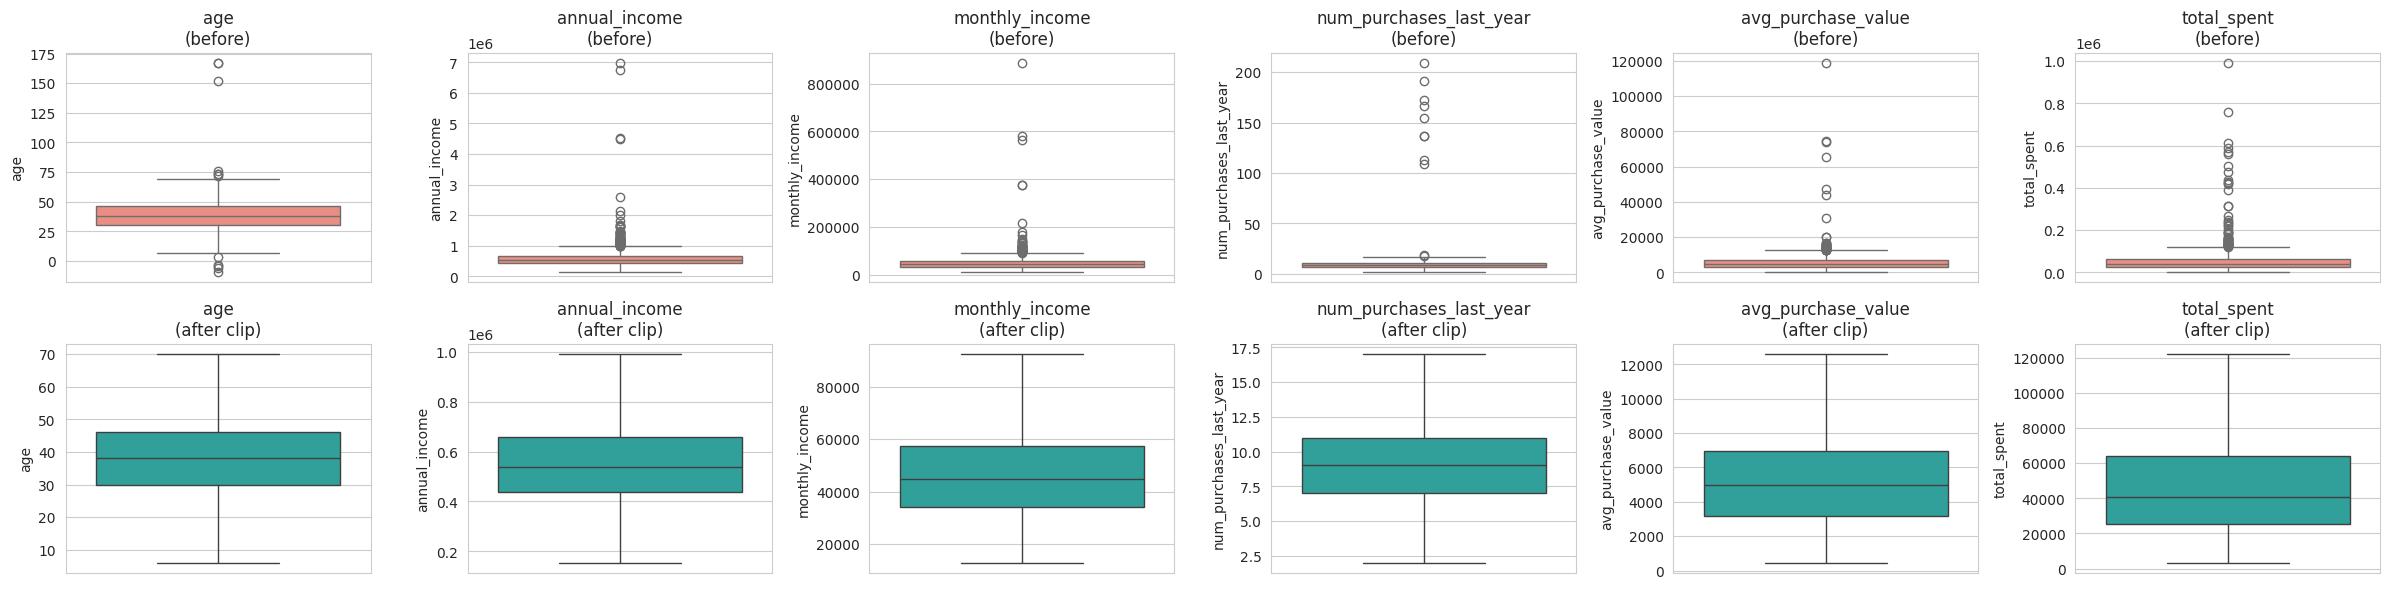

,column,lower_bound,upper_bound,outliers_found
0,age,6.00,70.00,12
1,annual_income,103367.28,991142.26,71
2,monthly_income,-568.57,92435.00,51
3,num_purchases_last_year,1.00,17.00,11
4,avg_purchase_value,-2492.53,12587.36,42
5,total_spent,-32708.97,122093.12,65


In [6]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_cols = ["age", "annual_income", "monthly_income", "num_purchases_last_year",
                 "avg_purchase_value", "total_spent"]

fig, axes = plt.subplots(2, len(outlier_cols), figsize=(4 * len(outlier_cols), 6))

report = []
for i, col in enumerate(outlier_cols):
    lower, upper = iqr_bounds(df[col])
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    report.append((col, round(lower, 2), round(upper, 2), int(n_outliers)))

    sns.boxplot(y=df[col], ax=axes[0, i], color="salmon")
    axes[0, i].set_title(f"{col}\n(before)")

    df[col] = df[col].clip(lower, upper)

    sns.boxplot(y=df[col], ax=axes[1, i], color="lightseagreen")
    axes[1, i].set_title(f"{col}\n(after clip)")

plt.tight_layout()
plt.show()

outlier_report = pd.DataFrame(report, columns=["column", "lower_bound", "upper_bound", "outliers_found"])
outlier_report


## 5. Phase 2 — Categorical Encoding (One-Hot)

Label-encoding nominal categories (e.g. `Karachi=0, Lahore=1, Islamabad=2`) invents a false ordinal distance between
classes an estimator will treat as real. One-hot encoding maps each class to its own orthogonal axis instead.


In [7]:
nominal_cols = ["gender", "city", "device_type", "email_signup"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
df.head()


,customer_id,age,annual_income,monthly_income,membership_years,num_purchases_last_year,avg_purchase_value,total_spent,last_purchase_days_ago,satisfaction_score,churned,gender_Male,city_Islamabad,city_Karachi,city_Lahore,city_Rawalpindi,device_type_Mobile,device_type_Tablet,email_signup_Yes
0,1.0,42.0,938944.46,78235.89,6.4,6.0,4137.80,25043.55,1.0,8.50,0.0,False,False,False,False,False,False,True,False
2,3.0,47.0,719951.68,59961.97,4.1,9.0,825.31,7005.66,177.0,6.06,0.0,False,False,True,False,False,True,False,False
3,4.0,49.0,335662.88,27919.67,3.8,11.0,5915.43,71984.50,4.0,5.82,0.0,False,False,True,False,False,True,False,True
4,5.0,15.0,657528.09,54791.15,3.8,4.0,7487.65,27324.08,216.0,7.40,1.0,False,False,True,False,False,False,False,False
5,6.0,22.0,759445.90,63288.42,0.9,4.0,4339.35,14924.75,378.0,8.70,1.0,False,True,False,False,False,True,False,False


## 6. Phase 2 — Multicollinearity Check & Eradication

`monthly_income` was deliberately built as a near-duplicate of `annual_income`. Left in, this makes `XᵀX` close to
singular and destabilizes any linear model's coefficients. The eradication algorithm: build the correlation matrix,
isolate pairs above the 0.80 threshold, and drop whichever member of the pair correlates **more weakly with the
target** — never just the first one found.


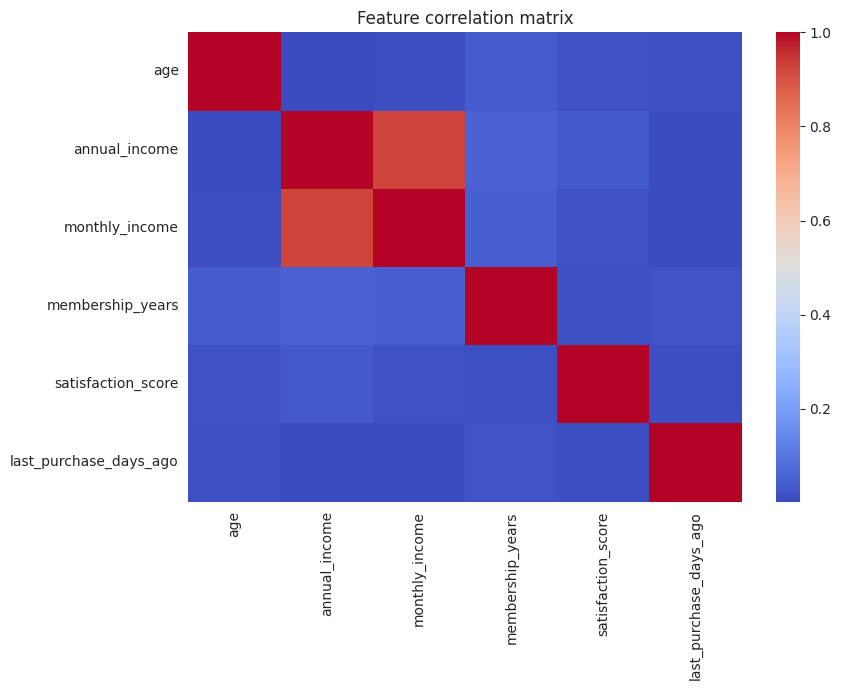

Collinear pairs found (|corr| > 0.80):
  monthly_income <-> annual_income: corr = 0.923
  -> dropping 'monthly_income' (weaker correlation with churned target)

Dropped columns: {'monthly_income'}


In [8]:
# Scope the scan to independent raw predictors. num_purchases_last_year / avg_purchase_value / total_spent
# are deliberately related by definition (total_spent is built from the other two) -- that's expected
# structure, not the redundant-data-collection problem we're hunting for. annual_income / monthly_income,
# on the other hand, are a genuine duplicate that should get caught.
numeric_cols = ["age", "annual_income", "monthly_income", "membership_years",
                 "satisfaction_score", "last_purchase_days_ago"]
corr_matrix = df[numeric_cols].corr().abs()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
collinear_pairs = [(col, row, upper.loc[row, col])
                    for col in upper.columns for row in upper.index
                    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.80]

print("Collinear pairs found (|corr| > 0.80):")
for a, b, c in collinear_pairs:
    print(f"  {a} <-> {b}: corr = {c:.3f}")

target_corr = df[numeric_cols].corrwith(df["churned"]).abs()
to_drop = set()
for a, b, _ in collinear_pairs:
    weaker = a if target_corr[a] < target_corr[b] else b
    to_drop.add(weaker)
    print(f"  -> dropping '{weaker}' (weaker correlation with churned target)")

df = df.drop(columns=list(to_drop))
print("\nDropped columns:", to_drop)


## 7. Feature Engineering — New Predictive Features

Four new features, each meant to encode a real behavioral signal rather than just recombine noise:

1. **`recency_frequency_score`** — purchases last year minus months since last purchase; an RFM-style engagement
   blend. Higher = more engaged, lower churn risk.
2. **`income_to_spend_ratio`** — income relative to spend; proxies discretionary spending headroom.
3. **`loyalty_value_index`** — tenure × average purchase value; captures loyalty-adjusted spending power.
4. **`is_high_value_customer`** — binary flag for customers above the 75th percentile of total spend.


In [9]:
df["recency_frequency_score"] = df["num_purchases_last_year"] - (df["last_purchase_days_ago"] / 30)

# Section 6 drops whichever of annual_income / monthly_income correlates weaker with the target,
# so reference whichever one actually survived.
income_col = "annual_income" if "annual_income" in df.columns else "monthly_income"
df["income_to_spend_ratio"] = df[income_col] / (df["total_spent"] + 1)
df["loyalty_value_index"] = df["membership_years"] * df["avg_purchase_value"]

spend_75th = df["total_spent"].quantile(0.75)
df["is_high_value_customer"] = (df["total_spent"] > spend_75th).astype(int)

new_features = ["recency_frequency_score", "income_to_spend_ratio", "loyalty_value_index", "is_high_value_customer"]
df[new_features].describe()


,recency_frequency_score,income_to_spend_ratio,loyalty_value_index,is_high_value_customer
count,1140.000000,1140.000000,1140.000000,1140.000000
mean,6.737778,19.264600,25956.442943,0.250000
std,3.878353,20.439464,19467.441493,0.433203
min,-9.066667,1.589084,0.000000,0.000000
25%,4.333333,8.005509,11528.807500,0.000000
50%,6.866667,13.353892,22444.761000,0.000000
75%,9.400000,22.082242,35143.701500,0.250000
max,17.000000,252.744440,127132.323375,1.000000


In [10]:
# quick sanity check: do the new features actually carry signal for the target?
print("Correlation of engineered features with churned target:")
print(df[new_features + ["churned"]].corr()["churned"].drop("churned").sort_values())


Correlation of engineered features with churned target:
recency_frequency_score   -0.184113
is_high_value_customer    -0.042609
loyalty_value_index       -0.013139
income_to_spend_ratio      0.035095
Name: churned, dtype: float64


## 8. Final Dataset & Export

The cleaned, encoded, decollinearized, feature-engineered dataset — ready to hand to a model.


In [11]:
print("Final shape:", df.shape)
df.info()
df.to_csv("shopsphere_cleaned.csv", index=False)
print("\nSaved -> shopsphere_cleaned.csv")


Final shape: (1140, 22)
<class 'pandas.DataFrame'>
Index: 1140 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1140 non-null   float64
 1   age                      1140 non-null   float64
 2   annual_income            1140 non-null   float64
 3   membership_years         1140 non-null   float64
 4   num_purchases_last_year  1140 non-null   float64
 5   avg_purchase_value       1140 non-null   float64
 6   total_spent              1140 non-null   float64
 7   last_purchase_days_ago   1140 non-null   float64
 8   satisfaction_score       1140 non-null   float64
 9   churned                  1140 non-null   float64
 10  gender_Male              1140 non-null   bool   
 11  city_Islamabad           1140 non-null   bool   
 12  city_Karachi             1140 non-null   bool   
 13  city_Lahore              1140 non-null   bool   
 14  city_Rawalpindi 

## 9. Conclusion

Recap against the Project 1 brief:

- [x] Missing data handled with the full decision matrix — row deletion, global median, group-wise median, mode, and
  KNN imputation, chosen by missingness band rather than guesswork.
- [x] Outliers isolated via IQR and neutralized with winsorization, preserving row count.
- [x] One-hot encoding used instead of label encoding to avoid inventing false ordinal distance.
- [x] Multicollinearity detected and eradicated by comparing each redundant pair's correlation with the target.
- [x] Four new predictive features engineered from existing columns.

**Key skills demonstrated:** Pandas, NumPy, statistical imputation, IQR-based outlier analysis, one-hot encoding,
correlation analysis, and feature extraction.
